# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Table Of Content
* [Each survey](#Each-survey)
* [Alens](#Alens)
* [Impact of Hillik](#Impact-of-Hillik)
* [Template tSZ](#Template-tSZ)
* [Template tSZ](#Template-kSZ)

## Each survey

In [2]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]

hillik_plk: 263583  179464  197081  196211 
hillik_spt: 822482  641454  614436  739384 
hillik_act: 859001  694859  854156  926618 


                         hillik_plk                 hillik_spt                 hillik_act
ombh2           =  0.022231 +/- 0.000210  |   0.023479 +/- 0.001864  |   0.021491 +/- 0.000647
omch2           =  0.119233 +/- 0.002030  |   0.113043 +/- 0.015402  |   0.131705 +/- 0.007546
theta           =  1.040778 +/- 0.000464  |   1.039671 +/- 0.006315  |   1.040766 +/- 0.001430
tau             =  0.056628 +/- 0.006561  |   0.054437 +/- 0.006725  |   0.055260 +/- 0.007101
ns              =  0.963211 +/- 0.005563  |   0.979379 +/- 0.021918  |   0.988789 +/- 0.010381
logA            =  3.043038 +/- 0.014406  |   2.983800 +/- 0.080656  |   3.066664 +/- 0.055347


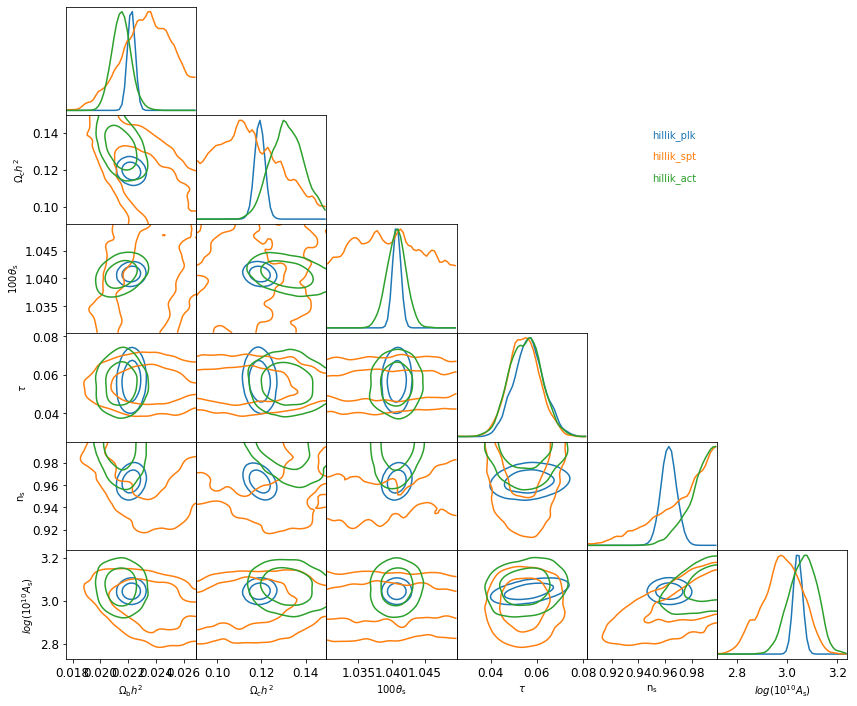

In [3]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)
print( "%35s %26s %26s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

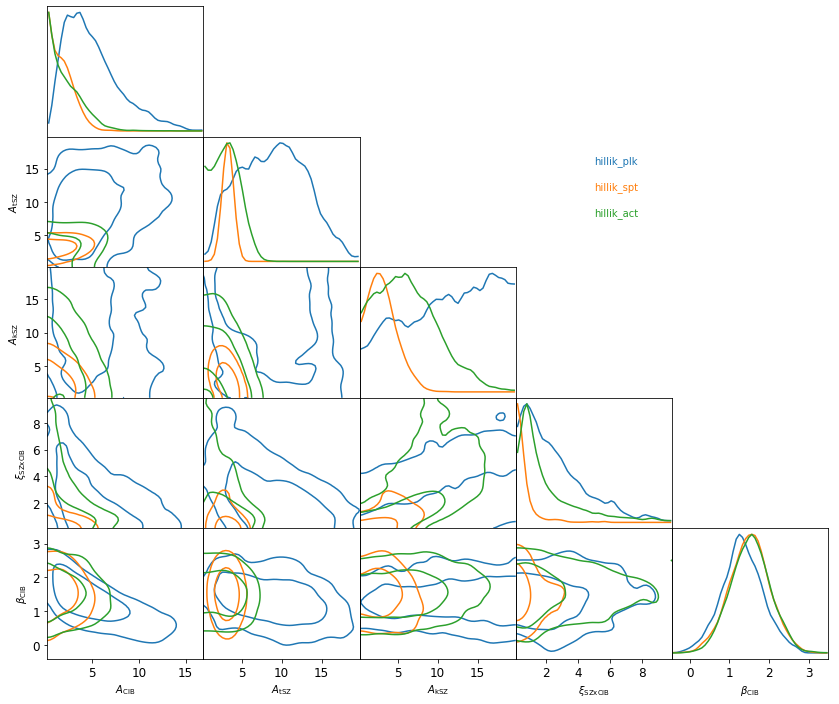

In [4]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Combination

In [5]:
runnames = ['hillik_plk','hillik_plkspt','hillik_plkact','hillik_plksptact']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]

hillik_plk: 263583  179464  197081  196211 
hillik_plkspt: 499286  493104  434884  484491 
hillik_plkact: 549082  721498  567786  643352 
hillik_plksptact: 731448  929774  718131  627443 


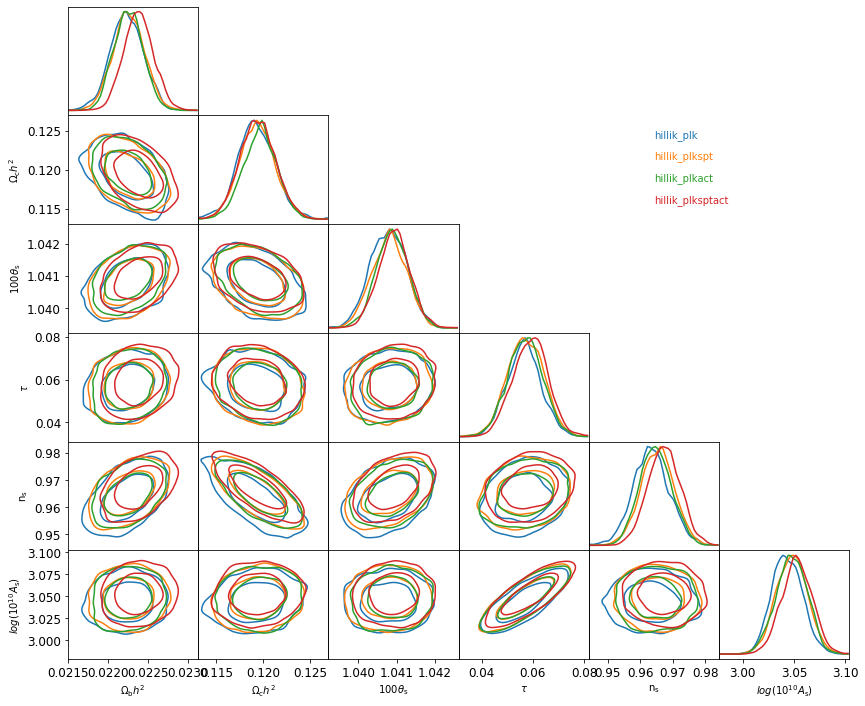

In [21]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [22]:
print( "%35s %27s %27s %27s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                         hillik_plk               hillik_plkspt               hillik_plkact            hillik_plksptact
ombh2           =  0.022235 +/- 0.000209  |   0.022258 +/- 0.000198  |   0.022258 +/- 0.000184  |   0.022384 +/- 0.000185
omch2           =  0.119194 +/- 0.002009  |   0.119350 +/- 0.001887  |   0.119710 +/- 0.001831  |   0.119400 +/- 0.001905
theta           =  1.040789 +/- 0.000472  |   1.040814 +/- 0.000464  |   1.040889 +/- 0.000415  |   1.040937 +/- 0.000412
tau             =  0.056612 +/- 0.006591  |   0.057108 +/- 0.007173  |   0.057030 +/- 0.006788  |   0.059303 +/- 0.006834
ns              =  0.963234 +/- 0.005635  |   0.965386 +/- 0.005072  |   0.964551 +/- 0.004935  |   0.967340 +/- 0.005085
logA            =  3.042864 +/- 0.014353  |   3.047957 +/- 0.015004  |   3.047964 +/- 0.014926  |   3.052790 +/- 0.014784


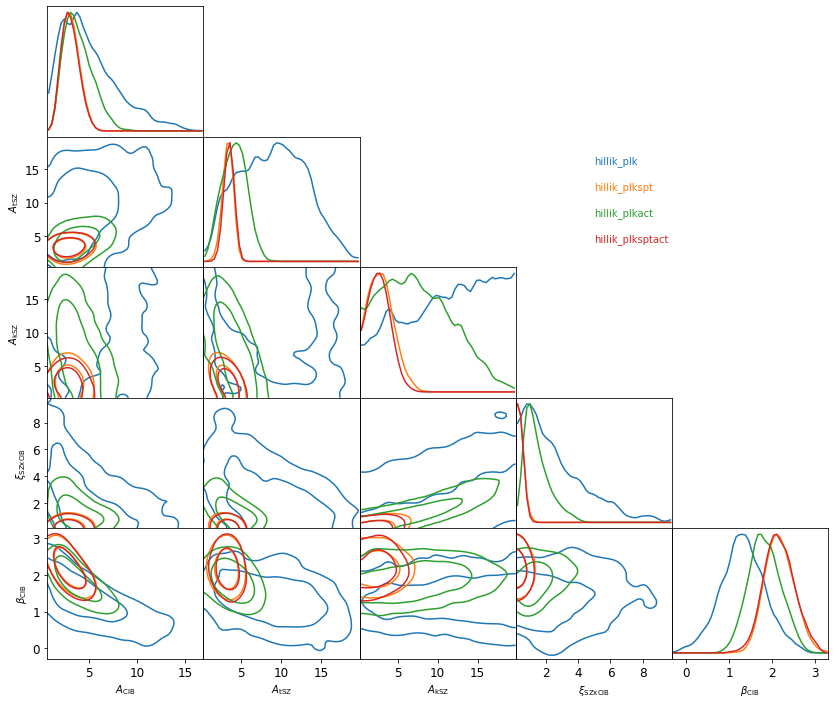

In [23]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Alens

In [24]:
runnames = ['hillik_plk_Alens','hillik_plkact_Alens','hillik_plkspt_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]

hillik_plk_Alens: 95949  201085  146245  136143 
hillik_plkact_Alens: 798541  650434  629458  593441 
hillik_plkspt_Alens: 473470  389992  535189  524216 
hillik_plksptact_Alens: 636386  498527  526738  432435 


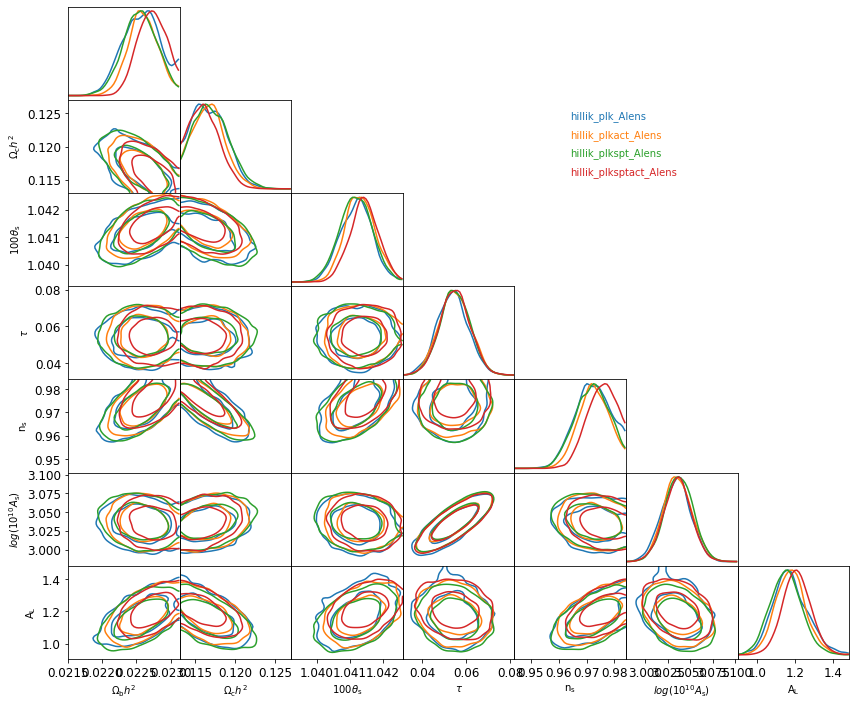

In [25]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.triangle( chains, listpar, labels=runnames, smooth=1.5)

In [26]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                   hillik_plk_Alens          hillik_plkact_Alens          hillik_plkspt_Alens       hillik_plksptact_Alens
ombh2           =  0.022614 +/- 0.000311  |   0.022602 +/- 0.000224  |   0.022565 +/- 0.000256  |   0.022747 +/- 0.000226
omch2           =  0.116255 +/- 0.002442  |   0.116452 +/- 0.002183  |   0.116607 +/- 0.002424  |   0.115754 +/- 0.002124
theta           =  1.041243 +/- 0.000488  |   1.041326 +/- 0.000456  |   1.041199 +/- 0.000495  |   1.041454 +/- 0.000442
tau             =  0.053753 +/- 0.007169  |   0.054395 +/- 0.007144  |   0.054702 +/- 0.006777  |   0.054708 +/- 0.006807
ns              =  0.973596 +/- 0.007962  |   0.973002 +/- 0.005935  |   0.972685 +/- 0.006584  |   0.976514 +/- 0.005974
logA            =  3.034585 +/- 0.016091  |   3.035213 +/- 0.015646  |   3.037161 +/- 0.015356  |   3.035951 +/- 0.015107
Alens           =  1.171218 +/- 0.091244  |   1.177601 +/- 0.076328  |   1.152633 +/- 0.081534  |   1.208499 +/- 0.070466


In [27]:
for i in range(len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.171 +/- 0.091 (1.88σ) hillik_plk_Alens
1.178 +/- 0.076 (2.33σ) hillik_plkact_Alens
1.153 +/- 0.082 (1.87σ) hillik_plkspt_Alens
1.208 +/- 0.070 (2.96σ) hillik_plksptact_Alens


## Impact of Hillik

In [31]:
#SZ sector
runnames = ['hillik_spt','hillik_plksptact','spt_fixedLCDM']
spt = [MCtools.mergeMC( f"{DBdir}/{run}/mcmc", burnin=0.9, nelts=5000) for run in runnames]
for k,v in {'Atsz':'czero_tsz','Aksz':'czero_ksz','Acib':'czero_dg_cl','xi':'tsz_dg_cor'}.items(): spt[-1][k] = spt[-1][v]

hillik_spt: 822482  641454  614436  739384 
hillik_plksptact: 731448  929774  718131  627443 
spt_fixedLCDM: 34761  45761  31241  46201 


Text(0, 0.5, 'D$^{kSZ}_{3000}\\quad(\\mu K^2)$')

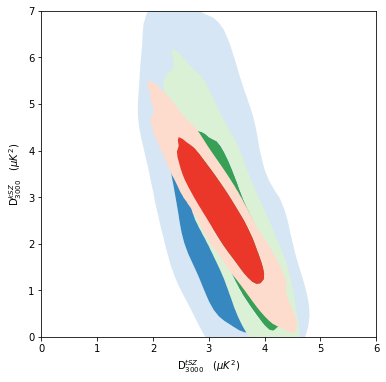

In [32]:
#Figure 3 [Reichard et al. 2020]
figure(figsize=(6,6))
for i,c in enumerate(['Blues','Greens','Reds']):
    MCtools.posterior2d(spt[i],'Atsz','Aksz', cmap=c, levels=[0.68,0.95], alpha=1)
xlim(0,6)
ylim(0,7)
xlabel('D$^{tSZ}_{3000}\quad(\mu K^2)$')
ylabel('D$^{kSZ}_{3000}\quad(\mu K^2)$')

Text(0, 6.2, 'tSZ')

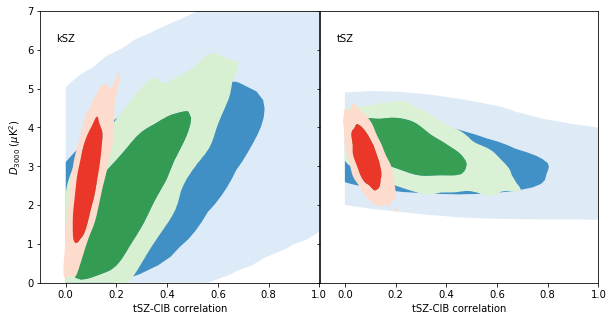

In [33]:
#Figure 4 Reichardt et al.
figure(figsize=(10,5))
subplot( 1, 2, 1)
for i,cm in enumerate(['Blues','Greens','Reds']):
    MCtools.posterior2d( spt[i], "xi", "Aksz", cmap=cm, levels=[0.68,0.95], alpha=1)
xlim(-0.1,1.)
ylim(0.,7)
ylabel( '$D_{3000}$ ($\\mu$K$^2$)')
xlabel( 'tSZ-CIB correlation')
text( 0, 6.2, 'kSZ', ha='center')
subplot( 1, 2, 2)
for i,cm in enumerate(['Blues','Greens','Reds']):
    MCtools.posterior2d( spt[i], "xi", "Atsz", cmap=cm, levels=[0.68,0.95], alpha=1)
subplots_adjust(wspace=0.001)
ylabel("")
gca().set_yticklabels([])
xlim(-0.1,1.)
ylim(0.,7)
xlabel( 'tSZ-CIB correlation')
text( 0, 6.2, 'tSZ', ha='center')

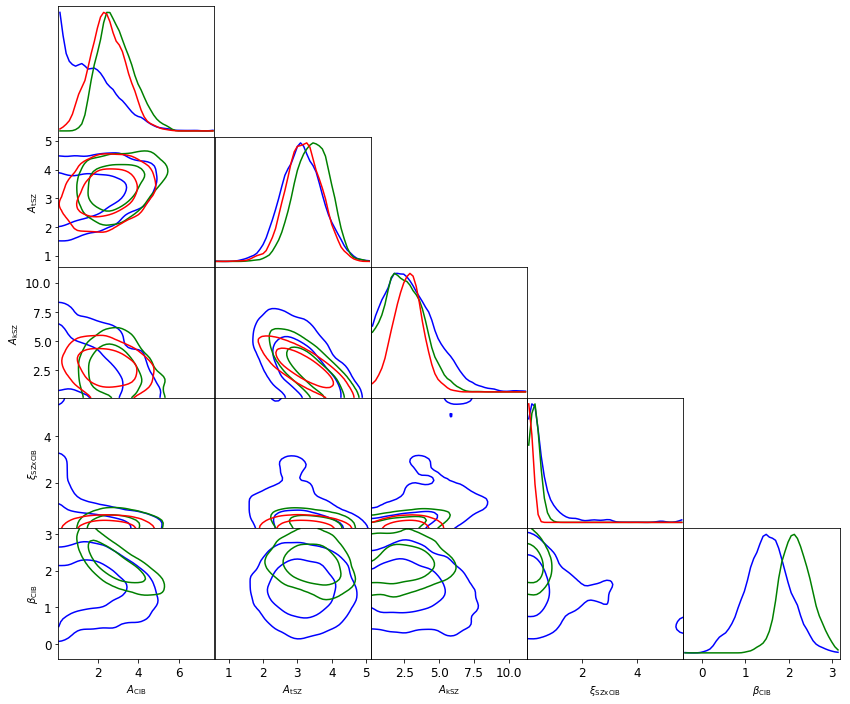

In [45]:
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( spt, listpar, labels=runnames, colors=['b','g','r'])

In [28]:
runnames = ['plk_spt_act','hillik_plksptact','plk_spt_act_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

plk_spt_act: 676200  586644  520265  501509 
hillik_plksptact: 731448  929774  718131  627443 
plk_spt_act_Alens: 484037  410584  519139  471037 
hillik_plksptact_Alens: 636386  498527  526738  432773 


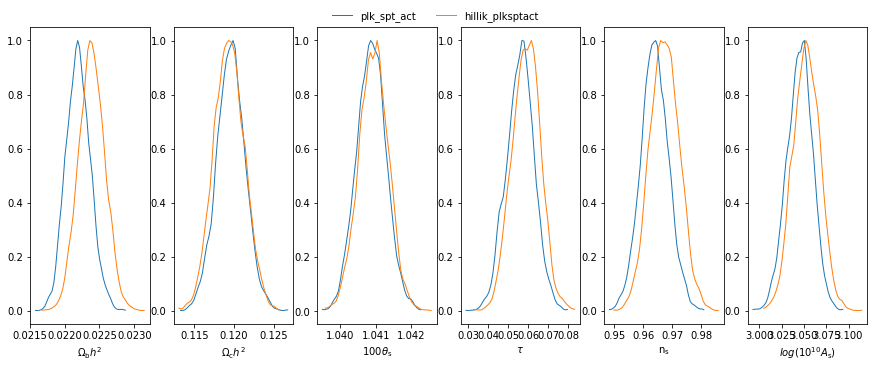

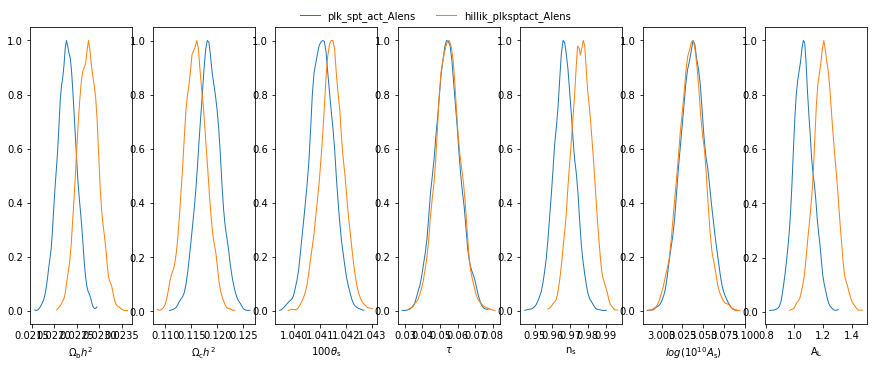

In [29]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.posterior1d( chains[:2], listpar[:-1], labels=runnames[:2], ncol=1, figsize=(15,5))
fig=MCtools.posterior1d( chains[2:], listpar, labels=runnames[2:], ncol=1, figsize=(15,5))

In [30]:
for i in range(2,len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.061 +/- 0.066 (0.92σ) plk_spt_act_Alens
1.209 +/- 0.071 (2.94σ) hillik_plksptact_Alens


# Template tSZ

<span style="color:red"> **not yet converged !!** </span>

In [64]:
runnames = ['tsz_shaw','tsz_batt','tsz_George','tsz_douspis']
chains = [MCtools.mergeMC( f"{DBdir}/hillik_plksptact_{run}/mcmc", burnin=0.9, nelts=10000) for run in runnames]

hillik_plksptact_tsz_shaw: 293774  242021  274720  217310 
hillik_plksptact_tsz_batt: 291600  282115  261857  284432 
hillik_plksptact_tsz_George: 258283  388761  278549  244384 
hillik_plksptact_tsz_douspis: 281308  269675  296776  281362 


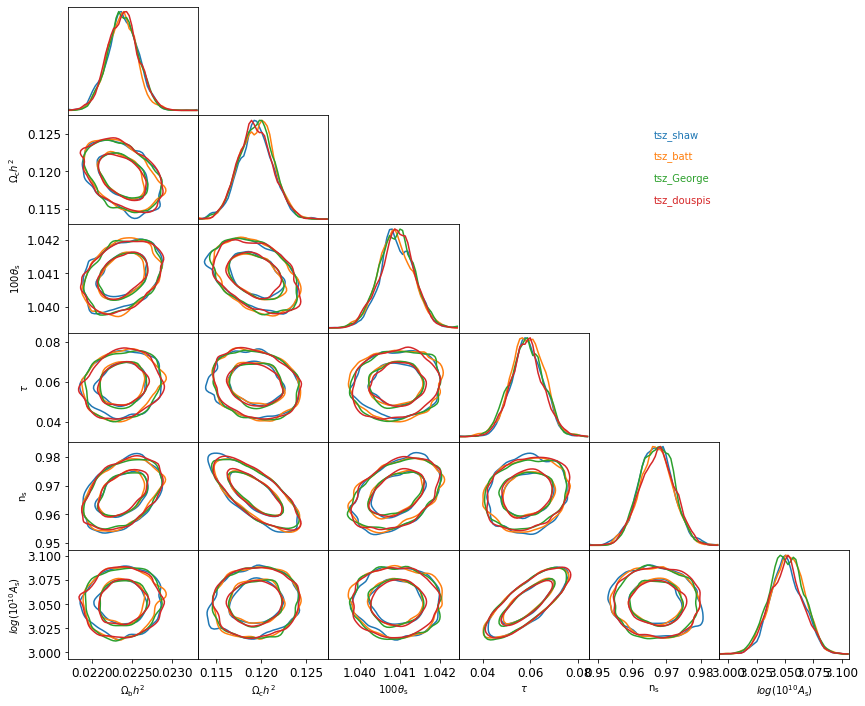

In [65]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

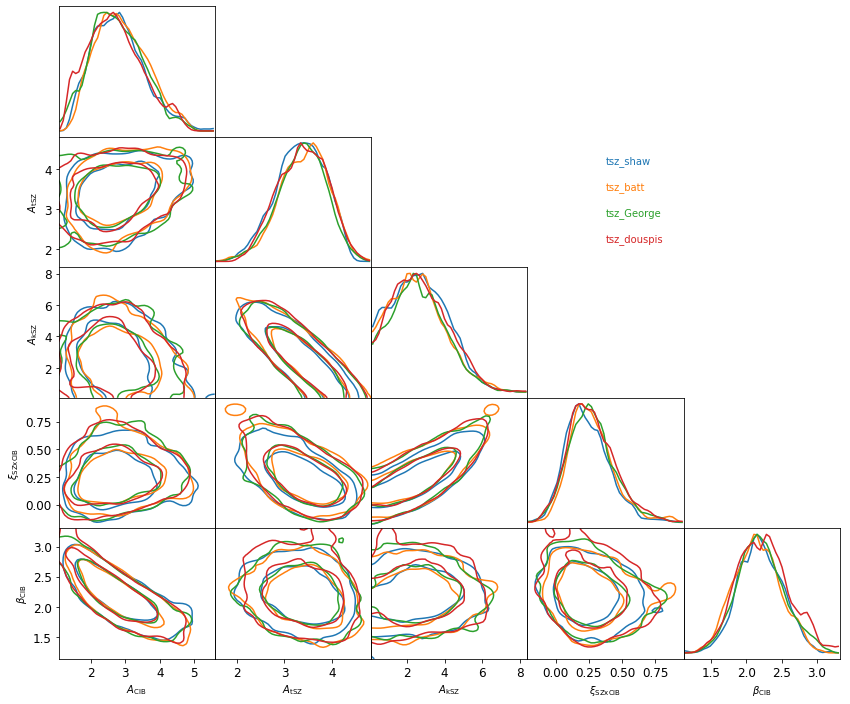

In [66]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

# Template kSZ

<span style="color:red"> **not yet converged !!** </span>

In [67]:
runnames = ['ksz_AGRF','ksz_Batt','ksz_CSFP','ksz_OZ','ksz_TBO']
chains = [MCtools.mergeMC( f"{DBdir}/hillik_plksptact_{run}/mcmc", burnin=0.9, nelts=10000) for run in runnames]

hillik_plksptact_ksz_AGRF: 337335  370140  406285  270416 
hillik_plksptact_ksz_Batt: 231640  284678  382263  297171 
hillik_plksptact_ksz_CSFP: 376019  363214  299290  367208 
hillik_plksptact_ksz_OZ: 290495  385627  272162  341076 
hillik_plksptact_ksz_TBO: 292146  478191  426153  360048 


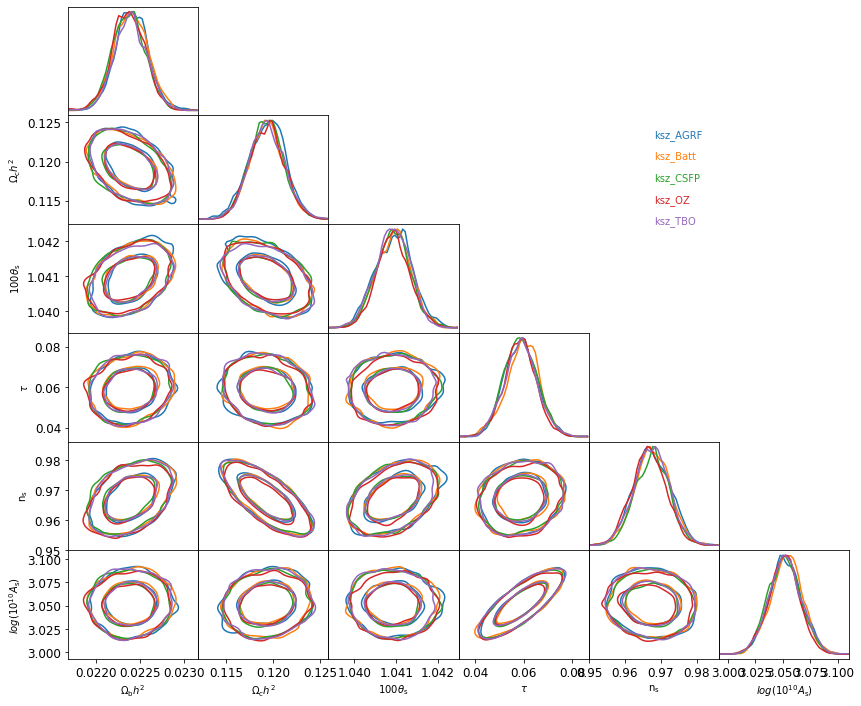

In [68]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

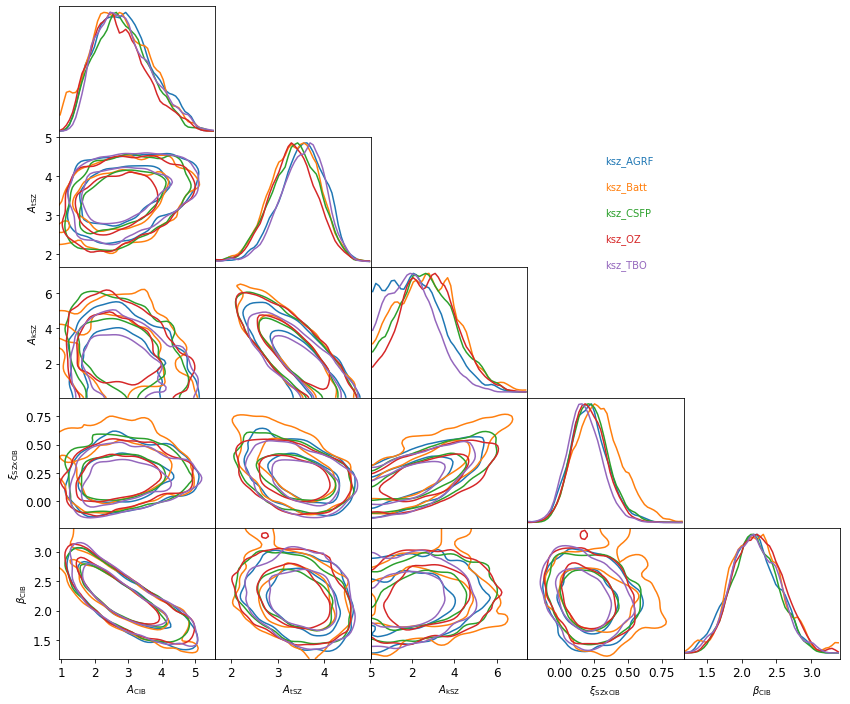

In [69]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)